In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 한글 폰트 설정
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# 시드 설정
np.random.seed(42)

print("-" * 60)
print("라이브러리 로드 완료")
print("한글 폰트 설정 완료!")
print("-" * 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [2]:
# 현재 작업 디렉토리(notebooks)의 부모 디렉토리(root)를 경로에 추가
os.chdir(os.path.abspath(".."))
print(os.getcwd())

df = pd.read_csv("data/2025_Airbnb_NYC_listings.csv").drop(columns="Unnamed: 0")
df.head()

d:\Dev\airbnb_price_prediction


,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,36121,city scrape,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,f,Prospect Heights,1.0,3.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",$200.00,90,365,90.0,90.0,365.0,365.0,90.0,365.0,NaN,t,27,57,87,362,2025-03-03,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,f,1,0,1,0,0.05
1,36647,city scrape,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,100%,f,East Harlem,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",$82.00,30,999,30.0,30.0,999.0,999.0,30.0,999.0,NaN,t,0,0,0,204,2025-03-03,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,f,1,0,1,0,0.58
2,38663,city scrape,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,100%,40%,f,Boerum Hill,1.0,3.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",$765.00,3,60,3.0,3.0,60.0,60.0,3.0,60.0,NaN,t,30,49,66,326,2025-03-02,43,0,0,267,0,0,0.0,2012-07-09,2023-08-30,4.70,4.83,4.52,4.88,4.88,4.86,4.62,OSE-STRREG-0001784,f,1,0,1,0,0.28
3,38833,city scrape,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",I have been a New Yorker for a long time\n and...,within an hour,100%,97%,t,Harlem,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",$139.00,2,45,2.0,2.0,1125.0,1125.0,2.0,1125.0,NaN,t,7,18,25,25,2025-03-03,241,42,3,25,43,255,35445.0,2010-08-28,2025-02-21,4.85,4.87,4.50,4.96,4.96,4.79,4.82,OSE-STRREG-0000476,

In [3]:
df_cleaned = pd.read_csv("data/df_cleaned.csv")

In [4]:
df_cleaned.shape

(22308, 109)

# 리뷰있음만 분리하기

In [5]:
# 리뷰 및 평점 관련 수치형 컬럼 정리
review_scores = [
    "number_of_reviews",
    "reviews_per_month",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "number_of_reviews_ly",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
]

df_reviews = df_cleaned[review_scores]

review_cols = [
    "number_of_reviews",
    "reviews_per_month",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "number_of_reviews_ly",
]
only_reviews = df_cleaned[review_cols]

detail_score_cols = [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
]

detail_scores = df_cleaned[detail_score_cols]

In [6]:
# 날짜 컬럼 변환
df_cleaned["first_review"] = pd.to_datetime(df_cleaned["first_review"])
df_cleaned["last_review"] = pd.to_datetime(df_cleaned["last_review"])

# 파생변수: 마지막 리뷰로부터 며칠이 지났는지
df_cleaned["days_since_last_review"] = (pd.to_datetime("today") - df_cleaned["last_review"]).dt.days

In [7]:
# 리뷰가 하나라도 있는 숙소 (평가됨)
has_reviews = df_cleaned[df_cleaned["number_of_reviews"] > 0].copy()

# 리뷰가 아예 없는 숙소 (미평가)
no_reviews = df_cleaned[df_cleaned["number_of_reviews"] == 0].copy()

# 결과 확인
print(f"평가된 숙소: {len(has_reviews)}개")
print(f"미평가 숙소: {len(no_reviews)}개")

평가된 숙소: 15510개
미평가 숙소: 6798개


## 단변량 분석 총정리 (리뷰/평점 컬럼 기준)

### 결측치 처리 (완료)
- 'number_of_reviews'가 0(리뷰 없음)인 경우, 다른 리뷰 관련 컬럼에 같은 수의 결측치 발생 확인, 월별 리뷰 수 ('reviews_per_month') 및 평점 관련 컬럼('review_scores_~') 결측치를 모두 0(리뷰 없음)으로 바꿈.
> 리뷰없음의 의미가 뭐지? 리뷰가 없으면, 경력이 없는 신규 호스트의 숙소고 리뷰가 있으면 경력이 있는 호스트의 숙소일까?
> host_since랑 다변량 분석

### 타입 및 통계 지표
- 타입 확인: 리뷰 개수는 정수형(int), 월별 리뷰수 및 평점 데이터는 연속형(float)
- 지표 확인

### 통계 지표 왜곡 가능성 발견 대박
- 0(리뷰 없음)의 비율이 전체의 30%이상 차지함: 전체 기준 평균 리뷰 개수(34개), 중앙값(5개) 및 평균 평점(약 3.28점)은 에어비앤비 데이터를 대표하지 못함. 실제 시장의 평가를 왜곡시키는 결과.
- 어떻게 해야 할까? 
  1. 평균 보다는 최빈값(Mode) 참고?
  2. 분석 목표인 숙소의 적정 가격('price') 예측 모델을 만들 때, '리뷰가 있는 숙소'와 '신규/미평가 숙소' 로 분리 분석 
> 파생 변수('has_review' = True/False)

In [8]:
# 데이터 타입, 결측치
df_reviews.info()

# 통계량 확인
display(df_reviews.describe().round(2))

# 리뷰없음(0) 제외되었는지 확인
(has_reviews.select_dtypes(include=["number"]) == 0).sum()

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   number_of_reviews            22308 non-null  int64  
 1   reviews_per_month            22308 non-null  float64
 2   number_of_reviews_ltm        22308 non-null  int64  
 3   number_of_reviews_l30d       22308 non-null  int64  
 4   number_of_reviews_ly         22308 non-null  int64  
 5   review_scores_rating         22308 non-null  float64
 6   review_scores_accuracy       22308 non-null  float64
 7   review_scores_cleanliness    22308 non-null  float64
 8   review_scores_checkin        22308 non-null  float64
 9   review_scores_communication  22308 non-null  float64
 10  review_scores_location       22308 non-null  float64
 11  review_scores_value          22308 non-null  float64
dtypes: float64(8), int64(4)
memory usage: 2.0 MB


,number_of_reviews,reviews_per_month,number_of_reviews_ltm,number_of_reviews_l30d,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00
mean,34.35,0.81,6.14,0.32,5.91,3.28,3.30,3.26,3.36,3.35,3.29,3.21
std,76.78,1.93,24.60,1.88,24.12,2.21,2.22,2.19,2.25,2.24,2.20,2.16
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5.00,0.21,0.00,0.00,0.00,4.69,4.74,4.64,4.83,4.83,4.67,4.56
75%,35.00,0.94,3.00,0.00,3.00,4.92,4.94,4.91,4.99,5.00,4.91,4.82
max,2749.00,117.98,1784.00,135.00,1797.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


id                                                  0
host_id                                             0
host_response_rate                                281
host_acceptance_rate                              698
host_listings_count                                 0
host_total_listings_count                           0
latitude                                            0
longitude                                           0
accommodates                                        0
bathrooms                                         106
bedrooms                                         1659
beds                                              327
price                                               0
minimum_nights                                      0
maximum_nights                                      0
minimum_minimum_nights                              0
maximum_minimum_nights                              0
minimum_maximum_nights                              0
maximum_maximum_nights      

In [9]:
# 리뷰 없는 숙소 비율
total_count = len(df_cleaned)
has_review_count = len(has_reviews)
no_review_count = len(no_reviews)

no_review_ratio = (no_review_count / total_count) * 100
has_review_ratio = (has_review_count / total_count) * 100

print(f"전체 숙소 중 리뷰가 없는(0) 숙소의 비율: {no_review_ratio:.2f}%\n")
print(f"전체 숙소 중 리뷰가 있는(>0) 숙소의 비율: {has_review_ratio:.2f}%\n")

전체 숙소 중 리뷰가 없는(0) 숙소의 비율: 30.47%

전체 숙소 중 리뷰가 있는(>0) 숙소의 비율: 69.53%



#### 리뷰 통계 왜곡 정정 (미평가 숙소 제외, 리뷰 있음만 분리해서 통계량 구함)
- 평균이 49.41 인데, 중앙값은 18 -> 초대박난 숙소들이 평균을 끌어올리고 있음

#### 평점 통계 왜곡 정정 (미평가 숙소 제외, 리뷰 있음만 분리해서 통계량 구함)
- 뉴욕 에어비앤비 숙소 평점의 하위 25%가 4.66으로 전체적으로 평점이 상향 평준화 되어있음을 확인
- 4.5 이하일 경우 만족도가 낮음으로 해석할 수 있음

In [10]:
# 리뷰 있는 숙소 일때 기초 통계량
display(df_cleaned.describe().round(2))
display(has_reviews.describe().round(2))

,id,host_id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_verifications_email,host_verifications_phone,host_verifications_work_email,log_price,log_estimated_revenue_l365d,has_self_checkin,has_wifi,has_kitchen,has_dryer,has_air_conditioning,has_heating,has_dedicated_workspace,has_hair_dryer,has_iron,has_gym,has_bbq_grill,has_breakfast,has_fireplace,has_smoking_allowed,has_pets_allowed,has_wine_glasses,has_crib,has_city_skyline_view,has_river_view,has_luggage_dropoff_allowed,has_long_term_stays_allowed,has_private_entrance,has_exterior_security_cameras,has_elevator,has_lock_on_bedroom_door,has_tub,has_washer,has_pool,has_alarm,has_garden_courtyard_view,has_outdoor,has_free_parking,amenities_count,count_appliances_expensive,has_ott,days_since_last_review
count,2.230800e+04,2.230800e+04,17915.00,18842.00,22288.00,22288.00,22308.00,22308.00,22308.00,22302.00,22259.00,22229.00,22308.00,22308.00,22308.00,22308.00,22308.00,2.230800e+04,2.230800e+04,22308.00,2.230800e+04,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,15510,15510,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.0,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.0,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,15510.00
mean,5.949318e+17,2.163476e+08,0.93,0.78,394.30,494.86,40.73,-73.94,2.92,1.19,1.32,1.65,213.84,27.25,473.22,27.00,42.13,9.683265e+04,1.733373e+06,28.23,9.391661e+05,16.47,36.16,57.38,239.72,34.35,6.14,0.32,204.03,5.91,71.56,11901.94,2021-03-31 16:53:39.806576,2024-03-03 08:07:42.359768,3.28,3.30,3.26,3.36,3.35,3.29,3.21,89.47,74.82,12.25,0.02,0.81,0.9,1.00,0.15,5.00,4.41,0.52,0.99,0.88,0.32,0.75,0.86,0.59,0.69,0.68,0.14,0.09,0.02,0.05,0.02,0.27,0.32,0.16,0.05,0.01,0.26,0.48,0.30,0.30,0.23,0.2,0.41,0.39,0.02,0.95,0.05,0.22,0.47,30.68,3.11,0.13,732.66
min,6.848000e+03,1.678000e+03,0.00,0.00,1.00,1.00,40.50,-74.25,1.00,0.00,0.00,0.00,7.00,1.00,1.00,1.00,1.00,1.000000e+00,1.000000e+00,1.00,1.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2009-05-25 00:00:00,2011-12-10 00:00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,2.08,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,369.00
25%,4.137269e+07,2.718154e+07,0.99,0.67,1.00,2.00,40.69,-73.98,2.00,1.00,1.00,1.00,85.00,30.00,120.00,30.00,30.00,1.820000e+02,3.650000e+02,30.00,3.600000e+02,1.00,12.00,29.00,151.00,0.00,0.00,0.00,126.00,0.00,0.00,0.00,2019-05-07 00:00:00,2023-10-04 00:00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.0,1.00,0.00,4.45,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,19.00

,id,host_id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_verifications_email,host_verifications_phone,host_verifications_work_email,log_price,log_estimated_revenue_l365d,has_self_checkin,has_wifi,has_kitchen,has_dryer,has_air_conditioning,has_heating,has_dedicated_workspace,has_hair_dryer,has_iron,has_gym,has_bbq_grill,has_breakfast,has_fireplace,has_smoking_allowed,has_pets_allowed,has_wine_glasses,has_crib,has_city_skyline_view,has_river_view,has_luggage_dropoff_allowed,has_long_term_stays_allowed,has_private_entrance,has_exterior_security_cameras,has_elevator,has_lock_on_bedroom_door,has_tub,has_washer,has_pool,has_alarm,has_garden_courtyard_view,has_outdoor,has_free_parking,amenities_count,count_appliances_expensive,has_ott,days_since_last_review
count,1.551000e+04,1.551000e+04,12560.00,13461.00,15493.00,15493.00,15510.00,15510.00,15510.00,15505.00,15487.00,15455.00,15510.00,15510.00,15510.00,15510.00,15510.00,1.551000e+04,1.551000e+04,15510.00,1.551000e+04,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.0,15510.00,15510.00,15510.00,15510,15510,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.0,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.0,15510.0,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00,15510.00
mean,4.249404e+17,1.899087e+08,0.94,0.80,77.90,112.37,40.73,-73.94,2.95,1.18,1.28,1.72,181.11,25.67,458.28,25.37,29.59,1.390501e+05,2.354403e+06,26.51,1.218256e+06,15.79,34.69,55.31,228.49,49.41,8.83,0.46,194.7,8.51,102.93,17118.53,2021-03-31 16:53:39.806576,2024-03-03 08:07:42.359768,4.72,4.75,4.69,4.83,4.81,4.73,4.61,27.99,21.53,5.59,0.01,1.16,0.91,1.00,0.12,4.93,6.34,0.55,0.99,0.9,0.31,0.71,0.93,0.62,0.77,0.76,0.1,0.1,0.03,0.06,0.02,0.25,0.37,0.14,0.07,0.01,0.31,0.51,0.32,0.34,0.21,0.23,0.43,0.33,0.01,0.96,0.06,0.25,0.58,33.66,3.36,0.18,732.66
min,6.848000e+03,1.678000e+03,0.00,0.00,1.00,1.00,40.50,-74.25,1.00,0.00,0.00,0.00,7.00,1.00,1.00,1.00,1.00,1.000000e+00,1.000000e+00,1.00,1.000000e+00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.0,0.00,0.00,0.00,2009-05-25 00:00:00,2011-12-10 00:00:00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,1.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,2.08,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,369.00
25%,2.951465e+07,2.225487e+07,1.00,0.71,1.00,2.00,40.68,-73.98,2.00,1.00,1.00,1.00,87.00,30.00,90.00,30.00,30.00,1.500000e+02,1.800000e+02,30.00,1.800000e+02,1.00,11.00,27.00,131.25,4.00,0.00,0.00,115.0,0.00,0.00,0.00,2019-05-07 00:00:00,2023-10-04 00:00:00,4.66,4.70,4.60,4.81,4.80,4.64,4.51,1.00,0.00,0.00,0.00,0.18,1.00,1.00,0.00,4.48,0.00,0.00,1.00,1.0,0.00,0.00,1.00,0.00,1.00,1.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,23.00,2.00,0.00

# 리뷰/평점 관련 컬럼들 분포 확인 (리뷰가 있는 숙소만)

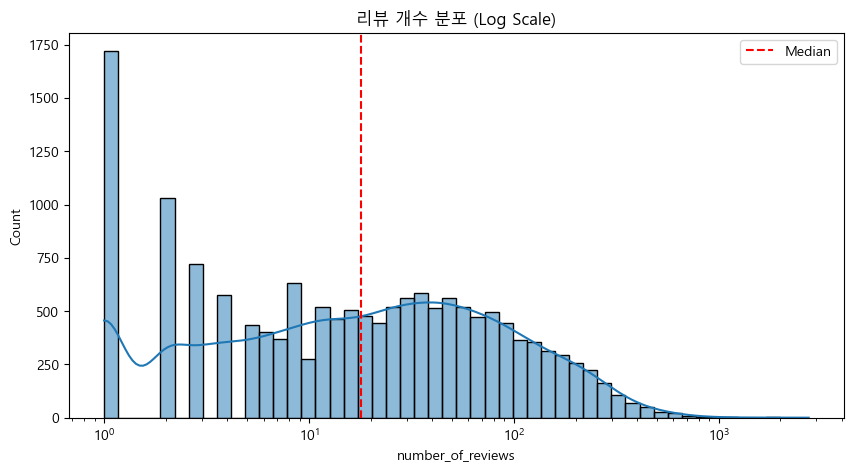

In [11]:
# 리뷰 개수 분포 시각화 (로그 스케일 적용 예시)
plt.figure(figsize=(10, 5))
sns.histplot(has_reviews["number_of_reviews"], bins=50, kde=True, log_scale=True)
plt.axvline(has_reviews["number_of_reviews"].median(), color="red", linestyle="--", label="Median")
plt.title("리뷰 개수 분포 (Log Scale)")
plt.legend()
plt.show()

#### 분포 특징
- 리뷰 개수 분포: 대부분의 숙소가 0 ~ 몇십개, 소수의 숙소가 몇백개 이상인 '긴꼬리 분포'.
- 평점 분포: 0점을 제외하면, 대부분의 평점이 4.0점 ~ 5.0점 사이에 집중. -> '없는 그룹(0점)'과 '매우 높은 그룹(4.5~5.0점)'으로 나뉘어 있음. -> 극단적

# 리뷰/평점 관련 컬럼들 이상치 분포 살펴보기

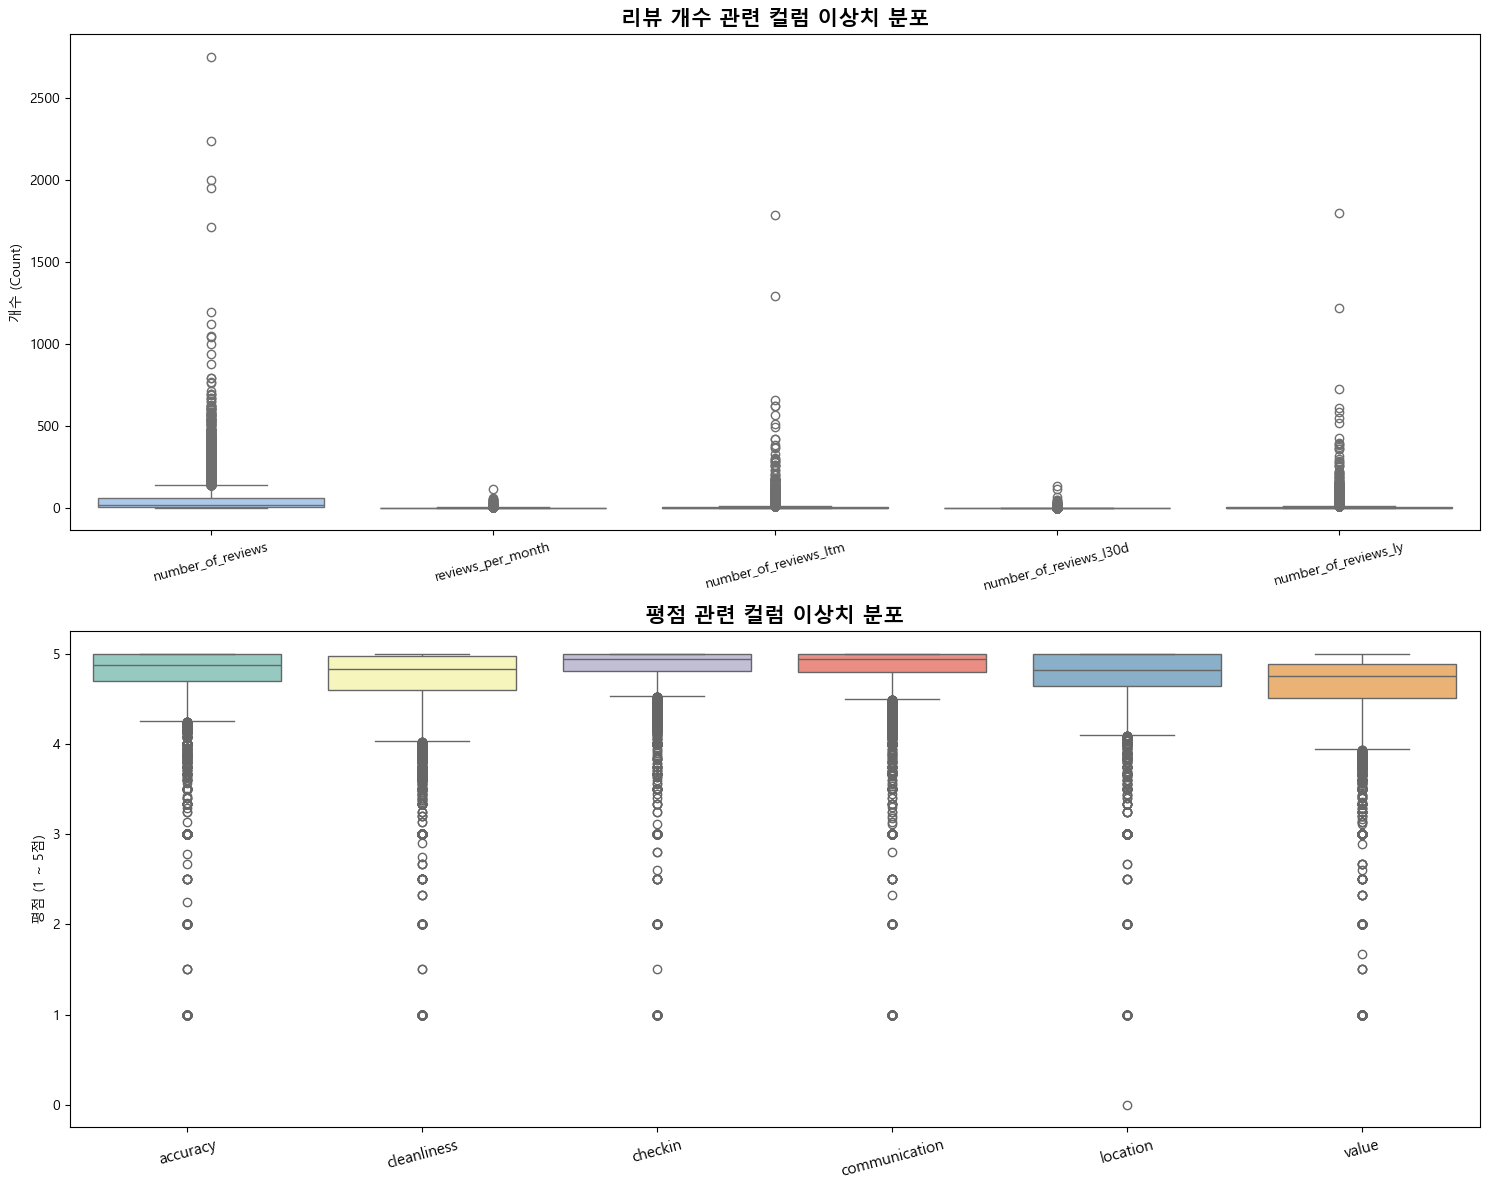

In [12]:
# 시각화
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12))

# 리뷰 개수 관련 이상치 (리뷰 없음 제외)
sns.boxplot(data=has_reviews[review_cols], ax=axes[0], palette="pastel")
axes[0].set_title("리뷰 개수 관련 컬럼 이상치 분포", fontsize=15, fontweight="bold")
axes[0].tick_params(axis="x", rotation=15)
axes[0].set_ylabel("개수 (Count)")

# 평점 관련 이상치 (리뷰 없음 제외)
sns.boxplot(data=has_reviews[detail_score_cols], ax=axes[1], palette="Set3")
axes[1].set_title("평점 관련 컬럼 이상치 분포", fontsize=15, fontweight="bold")

clean_labels = [col.replace("review_scores_", "") for col in detail_score_cols]
axes[1].set_xticklabels(clean_labels, rotation=15, fontsize=11)

axes[1].set_ylabel("평점 (1 ~ 5점)")

plt.tight_layout()
plt.show()

### 이상치
- 리뷰개수가 극단적으로 많은 숙소들은 '개인 호스트'보다 '기업형'일 확률이 높지 않을까?

# 다변량 분석 
- 리뷰 관련 이슈(패턴) 파악
- 평점 관련 이슈(패턴) 파악

In [13]:
# 리뷰 많은 순으로 데이터 정렬해서 패턴 찾아보기
cols = [
    "name",
    "host_name",
    "number_of_reviews",
    "price",
    "review_scores_rating",
    "host_is_superhost",
    "property_type",
    "room_type",
]

has_reviews[cols].sort_values("number_of_reviews", ascending=False).head()

,name,host_name,number_of_reviews,price,review_scores_rating,host_is_superhost,property_type,room_type
13316,"Safe and Cozy Hostel Room, 1 person, Manhattan",Alfred,2749,58.0,4.70,False,Private room in bed and breakfast,Private room
9458,Individual Cubicle Room in NYC/Mixed Floor,Alex And Zeena,2238,65.0,4.58,False,Private room in hostel,Private room
7870,Untitled at 3 Freeman - Studio Queen,Untitled,1998,159.0,4.88,True,Entire rental unit,Entire home/apt
4986,Amazing Micro Unit W/ communal rooftop and kit...,The Ridge,1951,162.0,4.54,False,Room in boutique hotel,Private room
10703,SoHo View Room (Full-Size Bed) in Hotel Comfort,SoHoBlu,1709,124.0,4.53,False,Entire loft,Entire home/apt


In [14]:
# 평점이 높은 순으로 정렬해서 패턴 파악해보기
cols = [
    "name",
    "host_name",
    "number_of_reviews",
    "price",
    "review_scores_rating",
    "host_is_superhost",
    "property_type",
    "room_type",
]

has_reviews[cols].sort_values("review_scores_rating", ascending=False).head()

,name,host_name,number_of_reviews,price,review_scores_rating,host_is_superhost,property_type,room_type
21699,NYC Skyline Penthouse 2Br/2Bath,Andrew,2,942.0,5.0,False,Entire rental unit,Entire home/apt
21697,Upscale Comfort: Stylish 2BR in the Heart of NYC,Krystian,2,344.0,5.0,True,Entire rental unit,Entire home/apt
21674,Spacious 3BR Family Haven in Lower Manhattan,Rouzbeh,2,465.0,5.0,False,Entire rental unit,Entire home/apt
21339,Modern Two Bedroom in NYC!,Frank,4,241.0,5.0,False,Entire rental unit,Entire home/apt
21228,Private Room Home Cinema Queens,Wayne,5,100.0,5.0,False,Private room in home,Private room


### 세부 평점이 전체 평점에 얼마나 영향을 주고 있는지?
- 세부 평점의 영향 정도 피익할 필요성 → 전체 평점과의 상관관계 파악

In [15]:
# 세부 평점 컬럼들
# detail_score_cols

# 리뷰가 있는 숙소 중에서, 세부 평점 평균 + 높은 순으로 정렬
detail_score_means = has_reviews[detail_score_cols].mean().sort_values(ascending=False)

display(detail_score_means.round(3))

review_scores_checkin          4.831
review_scores_communication    4.813
review_scores_accuracy         4.753
review_scores_location         4.729
review_scores_cleanliness      4.688
review_scores_value            4.613
dtype: float64

##### 리뷰가 있는 숙소의, 세부평점 평균 분석:
- 평균 평점이 가장 높은 것: chekin 과 communication 과 같은 호스트와의 직접적인 상호작용 점수 
-> 관대함 이슈 (사람은 예쁘게 봐줌)
- 평균 평점이 가장 낮은 것: value, cleanlines 가성비와 청결도 -> 깐깐하게 점수준다. (돈, 청결 민감)
- accuracy, location 과 같은 실제 장소적 특징들은 중간대 점수 → 관대 깐깐 반반 이슈

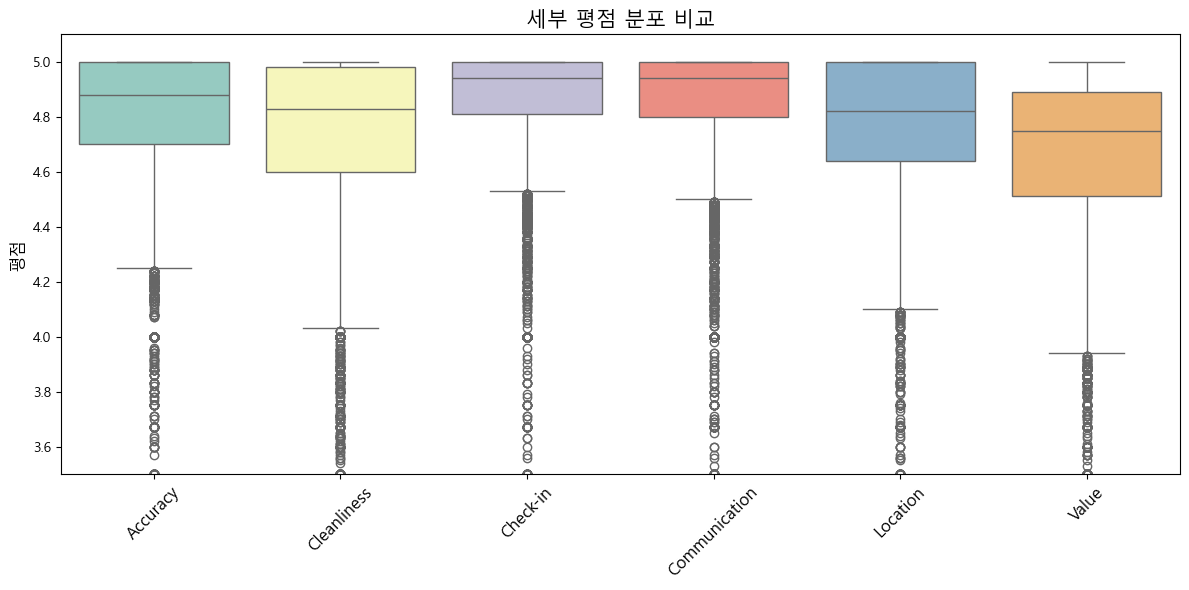

In [16]:
# Boxplot 시각화
plt.figure(figsize=(12, 6))

sns.boxplot(data=has_reviews[detail_score_cols], palette="Set3")
plt.title("세부 평점 분포 비교", fontsize=15)

clean_labels = ["Accuracy", "Cleanliness", "Check-in", "Communication", "Location", "Value"]
plt.xticks(ticks=range(len(detail_score_cols)), labels=clean_labels, rotation=45, fontsize=12)
plt.ylabel("평점", fontsize=12)
plt.ylim(3.5, 5.1)
plt.tight_layout()
plt.show()

# 리뷰/평점 과 다른 컬럼들 상관계수 살펴보기

In [17]:
# 리뷰,평점이랑 다른 수치형 컬럼들 한번에 상관계수 확인
review_related_cols = [
    "host_id",
    "host_listings_count",
    "host_total_listings_count",
    "host_response_rate",
    "host_acceptance_rate",
    "price",
    "accommodates",
    "bathrooms",
    "estimated_occupancy_l365d",
]

# df_cleaned를 베이스로 하되, 조건만 '리뷰 > 0'으로 필터링
# 이렇게 하면 review_related_cols에 있는 모든 컬럼을 안전하게 참조
result = (
    df_cleaned.loc[
        df_cleaned["number_of_reviews"] > 0, review_related_cols + ["review_scores_rating", "number_of_reviews"]
    ]
    .corr()[["review_scores_rating", "number_of_reviews"]]
    .sort_values("review_scores_rating", ascending=False)
)

display(result)

,review_scores_rating,number_of_reviews
review_scores_rating,1.000000,0.066157
estimated_occupancy_l365d,0.110858,0.264755
host_response_rate,0.069113,0.059699
number_of_reviews,0.066157,1.000000
price,0.043957,-0.040268
bathrooms,0.012022,-0.060838
accommodates,0.002404,-0.012126
host_acceptance_rate,0.000037,0.130313
host_id,-0.109332,-0.118294
host_listings_count,-0.115952,-0.074054


In [18]:
# 세부 평점 컬럼들
# detail_score_cols

# 영향을 주는 요인들
other_cols = [
    "host_id",
    "host_listings_count",
    "host_total_listings_count",
    "host_response_rate",
    "host_acceptance_rate",
    "price",
    "accommodates",
    "bathrooms",
    "estimated_occupancy_l365d",
    "number_of_reviews",
    "review_scores_rating",
]

all_target_cols = detail_score_cols + other_cols

corr_matrix = df_cleaned.loc[df_cleaned["number_of_reviews"] > 0, all_target_cols].corr()
detail_corr_view = corr_matrix.loc[other_cols, detail_score_cols]

detail_corr_view.sort_values(by="review_scores_rating", axis=1, ascending=False)

,review_scores_accuracy,review_scores_value,review_scores_communication,review_scores_cleanliness,review_scores_checkin,review_scores_location
host_id,-0.115556,-0.100978,-0.097601,-0.057282,-0.100309,-0.094504
host_listings_count,-0.094071,-0.170163,-0.157632,-0.065064,-0.096281,-0.029272
host_total_listings_count,-0.110757,-0.174413,-0.158997,-0.070932,-0.106184,-0.035696
host_response_rate,0.056289,0.054140,0.100481,0.069772,0.048293,0.019901
host_acceptance_rate,0.006225,0.005885,0.017948,0.040784,0.004488,-0.025075
price,0.034710,0.012483,0.023769,0.055828,0.022294,0.085831
accommodates,0.003727,-0.004476,0.014918,0.020362,-0.001980,-0.005515
bathrooms,-0.003146,0.015008,-0.002648,0.001537,0.007603,-0.002995
estimated_occupancy_l365d,0.101137,0.103298,0.092192,0.119265,0.083278,0.067646
number_of_reviews,0.085623,0.113258,0.077162,0.088116,0.070137,0.036592


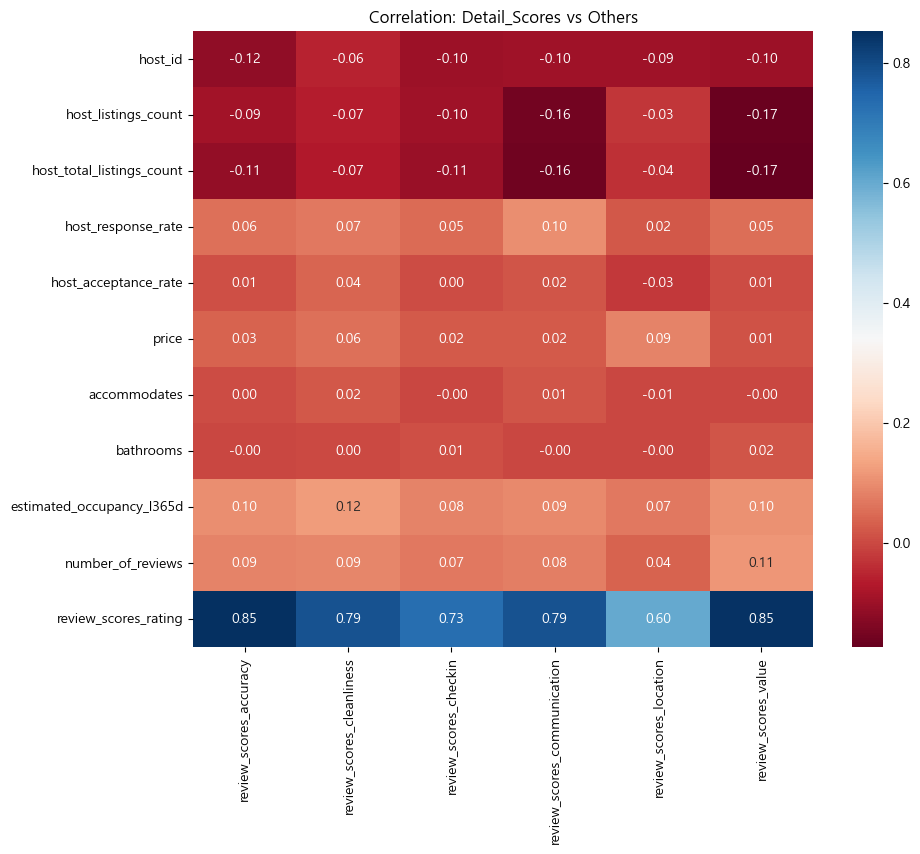

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(detail_corr_view, annot=True, cmap="RdBu", fmt=".2f")
plt.title("Correlation: Detail_Scores vs Others")
plt.show()

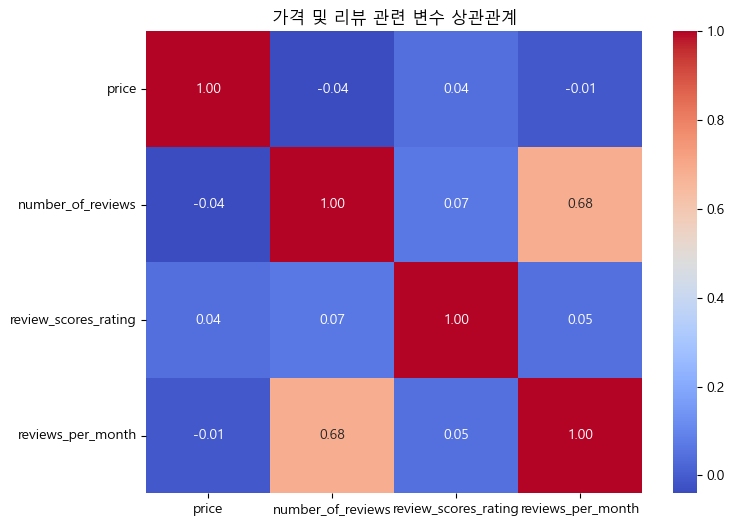

In [20]:
# 주요 수치형 변수들 간의 상관관계 히트맵
cols_to_corr = ["price", "number_of_reviews", "review_scores_rating", "reviews_per_month"]
plt.figure(figsize=(8, 6))
sns.heatmap(has_reviews[cols_to_corr].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("가격 및 리뷰 관련 변수 상관관계")
plt.show()

### 다변량 분석에 활용할 host_since 컬럼 타입, 형태 확인

In [21]:
df_cleaned["host_since"].info()

<class 'pandas.Series'>
RangeIndex: 22308 entries, 0 to 22307
Series name: host_since
Non-Null Count  Dtype
--------------  -----
22288 non-null  str  
dtypes: str(1)
memory usage: 174.4 KB


In [22]:
df_cleaned["host_since"].isna().sum()

np.int64(20)

In [23]:
# 결측치 확인 및 처리
# df_cleaned[df_cleaned["host_since"].isna()][["host_since"]]

host_since_mode = df_cleaned["host_since"].mode()[0]

df_cleaned["host_since"] = df_cleaned["host_since"].fillna(host_since_mode)

df_cleaned["host_since"].isna().sum()

np.int64(0)

In [24]:
df_cleaned["host_since"] = pd.to_datetime(df_cleaned["host_since"])

# 다변량 분석
- host since 활용, 경력 계산 -> 경력과 다른 컬럼들 간의 상관관계 살펴보기

## 최신 스크랩 날짜(2025/03/02) 와 host_since(가입날짜)를 활용해서 호스트 활동 경력 구하기 

In [25]:
df_cleaned["host_since"]

0       2009-12-11
1       2010-07-04
2       2010-07-13
3       2010-07-14
4       2010-07-16
           ...    
22303   2015-07-30
22304   2022-10-10
22305   2015-03-30
22306   2021-06-15
22307   2022-10-10
Name: host_since, Length: 22308, dtype: datetime64[us]

In [26]:
# 기준일 설정 (위에서 host_since 날짜 데이터 변환 완료)
base_date = datetime(2025, 3, 2)

# 호스트 경력(기간) 계산
df_cleaned["host_tenure_days"] = (base_date - df_cleaned["host_since"]).dt.days

# 상관계수 확인
# 호스트 경력과 세부 평점들 간의 상관계수
df_valid = df_cleaned[(df_cleaned[detail_score_cols] > 0).all(axis=1)]
tenure_corr = df_valid[detail_score_cols + ["host_tenure_days"]].corr().sort_values("host_tenure_days")
tenure_corr = tenure_corr.drop("host_tenure_days").sort_values(by="host_tenure_days", ascending=False)

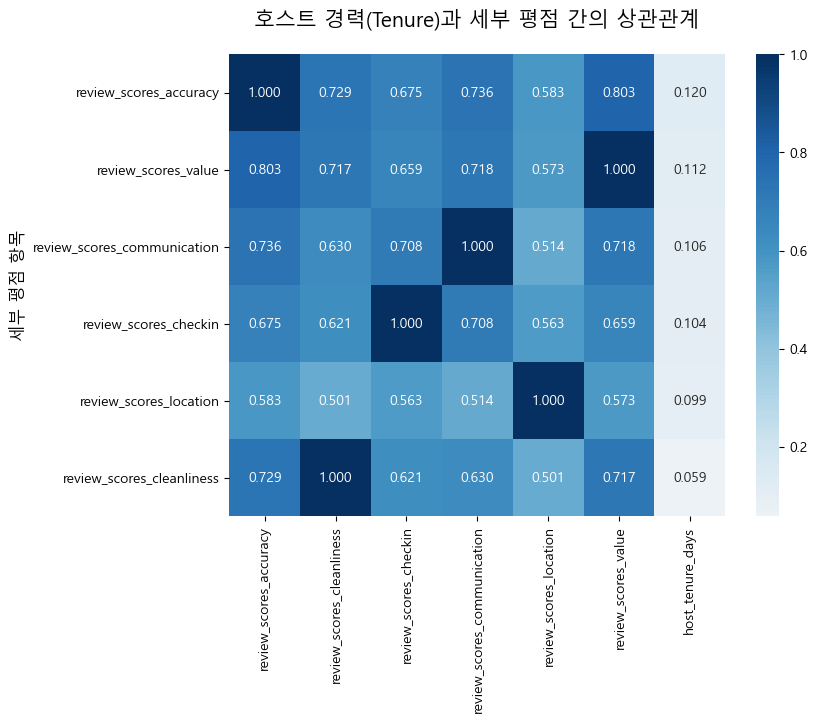

,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,host_tenure_days
review_scores_accuracy,1.000000,0.729387,0.675249,0.736107,0.583130,0.803235,0.119934
review_scores_value,0.803235,0.717492,0.659378,0.717933,0.572677,1.000000,0.111846
review_scores_communication,0.736107,0.629893,0.708273,1.000000,0.514133,0.717933,0.105708
review_scores_checkin,0.675249,0.621361,1.000000,0.708273,0.562808,0.659378,0.104029
review_scores_location,0.583130,0.500813,0.562808,0.514133,1.000000,0.572677,0.098522
review_scores_cleanliness,0.729387,1.000000,0.621361,0.629893,0.500813,0.717492,0.058774


In [27]:
# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(tenure_corr, annot=True, fmt=".3f", cmap="RdBu", center=0)

plt.title("호스트 경력(Tenure)과 세부 평점 간의 상관관계", fontsize=15, pad=20)
plt.ylabel("세부 평점 항목", fontsize=12)
plt.show()

# 결과 값 출력
display(tenure_corr)

<Axes: xlabel='host_since', ylabel='Count'>

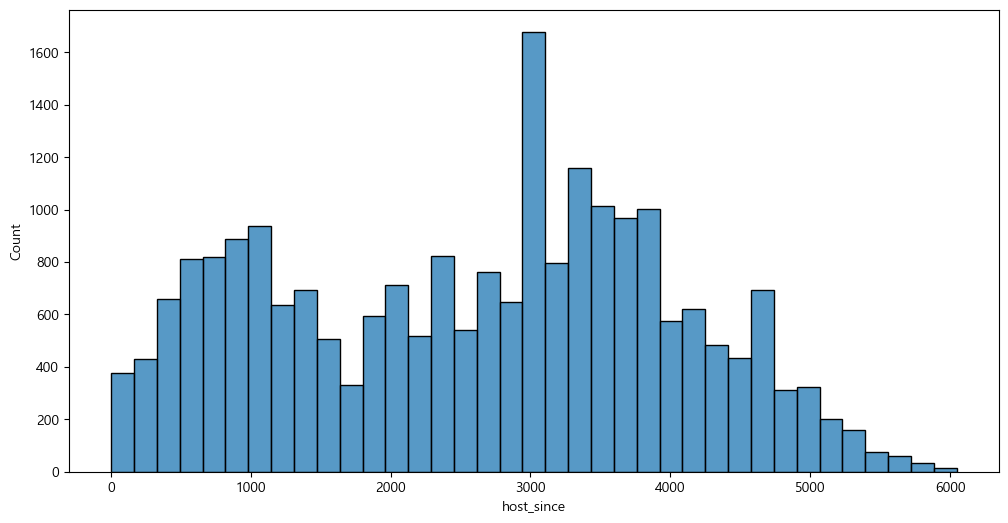

In [28]:
sns.histplot((base_date - df_cleaned["host_since"]).dt.days)

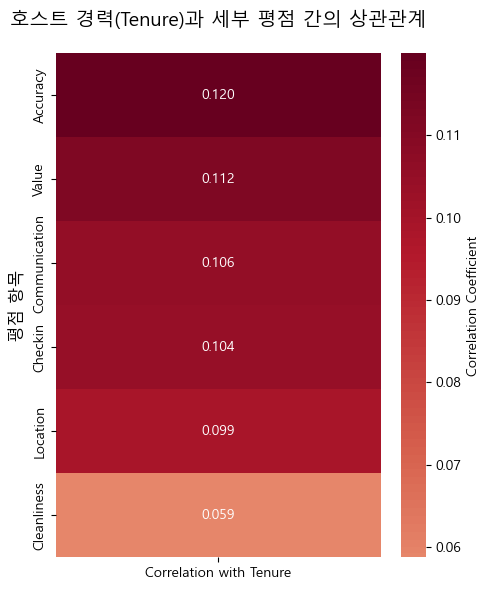

In [29]:
# 평점이 0보다 커야, 경력과 평점의 관계를 볼 수 있음
df_valid = df_cleaned[df_cleaned[detail_score_cols].gt(0).all(axis=1)].copy()

# 상관계수 계산 후 'host_tenure_days'와의 상관계수만 보기
corr_matrix = df_valid[detail_score_cols + ["host_tenure_days"]].corr()
tenure_corr = corr_matrix.loc[detail_score_cols, ["host_tenure_days"]].sort_values(
    by="host_tenure_days", ascending=False
)

# 컬럼명 줄이기
tenure_corr.index = [col.replace("review_scores_", "").capitalize() for col in tenure_corr.index]
tenure_corr.columns = ["Correlation with Tenure"]

# 히트맵 시각화
plt.figure(figsize=(5, 6))
sns.heatmap(
    tenure_corr,
    annot=True,  # 수치 표시
    fmt=".3f",  # 소수점 셋째자리까지
    cmap="RdBu_r",  # 빨강, 파랑
    center=0,  # 0을 기준으로 색상 설정
    cbar_kws={"label": "Correlation Coefficient"},
)

plt.title("호스트 경력(Tenure)과 세부 평점 간의 상관관계", fontsize=14, pad=20)
plt.ylabel("평점 항목", fontsize=12)
plt.tight_layout()
plt.show()

In [30]:
from scipy import stats

# 유의성, 효과크기, 결정계수까지 같이 보기
results = []

for col in detail_score_cols:
    # 결측치 제거 후 계산
    mask = df_valid[col].notna() & df_valid["host_tenure_days"].notna()
    r, p_value = stats.pearsonr(df_valid.loc[mask, "host_tenure_days"], df_valid.loc[mask, col])

    # 효과크기 해석
    if abs(r) < 0.1:
        effect_size = "Pass (무시 가능)"
    elif abs(r) < 0.3:
        effect_size = "Small (작음)"
    elif abs(r) < 0.5:
        effect_size = "Medium (중간)"
    else:
        effect_size = "Large (큼)"

    results.append(
        {
            "항목": col.replace("review_scores_", "").capitalize(),
            "상관계수(r)": round(r, 4),
            "p-value": f"{p_value:.4e}",
            "유의성(p < 0.05)": "유의함" if p_value < 0.05 else "유의하지 않음",
            "효과크기": effect_size,
            "결정계수(r^2)": f"{r**2:.2%}",  # 변동성 설명력
        }
    )

# 결과 출력
analysis_df = pd.DataFrame(results)
display(analysis_df)

,항목,상관계수(r),p-value,유의성(p < 0.05),효과크기,결정계수(r^2)
0,Accuracy,0.1199,8.6767e-51,유의함,Small (작음),1.44%
1,Cleanliness,0.0588,2.3859e-13,유의함,Pass (무시 가능),0.35%
2,Checkin,0.1040,1.4049e-38,유의함,Small (작음),1.08%
3,Communication,0.1057,8.7339e-40,유의함,Small (작음),1.12%
4,Location,0.0985,9.2407e-35,유의함,Pass (무시 가능),0.97%
5,Value,0.1118,2.3284e-44,유의함,Small (작음),1.25%


호스트 경력과 평점의 관계:
- 경력이 쌓일수록 어떤 평점이 오르거나 내리는가?
- gt(0).all(axis=1) 필터링을 통해 평점이 없는 숙소를 분석에서 제외
- 전체적으로 0.1의 상관계수로, 상관이 뚜렷하게 있다고 보기 어렵지만, 경력이 평점에 어떤 영향을 미치고 있음은 알 수 있다.(0.1~0.2 정도의 상관계수는 '약하지만 무시할 수 없는 관계')
- 경력이 쌓인 호스트일 수록 평점 관리 노하우를 터득했을 가능성.(Communication(소통)**이나 Check-in(체크인) 점수와 경력의 상관계수가 0.1)
-----------------------------------------------------------------------------------------------------------------------------
- 경력과 청결도는 관련성이 낮음: 등록된 숙소가 노후화 됨에 따라 청결도를 유지하기 어려울 것으로 예상해 봄. 
- 이 가설을 검증하기 위해 property_type별로 나누어 보거나, 가격대별(고가/저가) 청결도와 경력의 상관관계를 다시 확인. (예: 고가 숙소는 경력이 길어도 리모델링을 통해 청결도를 유지할 것이라는 반대 가설 가능)

##### "분석 결과, 호스트의 경력이 평점 전반에 긍정적인 영향을 미치지만, 청결도만큼은 경력만으로 해결되지 않는 영역임을 확인했습니다. 따라서 장기 운영 호스트를 대상으로 한 '숙소 리프레시(리모델링/청소 서비스) 프로모션'이 플랫폼 차원에서 필요할 것으로 보입니다."

In [31]:
# 호스트 경력과 가격 간의 상관관계 확인
price_tenure_corr = df_cleaned[["host_tenure_days", "log_price"]].corr().iloc[0, 1]
print(f"호스트 경력과 가격 간의 상관계수: {price_tenure_corr:.4f}")

호스트 경력과 가격 간의 상관계수: 0.0110


## 호스트 시작 연도별 혹은 연차별로 세부 평점 평균 비교 
- "~년에 시작한 호스트들이 유독 ~평점이 높다"

In [32]:
# '호스트 연차(Years)' 컬럼 생성 (일수를 365로 나눔)
df_cleaned["host_tenure_years"] = df_cleaned["host_tenure_days"] / 365
df_valid["host_tenure_years"] = df_valid["host_tenure_days"] / 365

# 연차(tenure_group)
bins = [0, 1, 3, 5, 10, 20]
labels = ["1년 미만", "1-3년", "3-5년", "5-10년", "10년 이상"]

df_cleaned["tenure_group"] = pd.cut(df_cleaned["host_tenure_years"], bins=bins, labels=labels, right=False)
df_valid["tenure_group"] = pd.cut(df_valid["host_tenure_years"], bins=bins, labels=labels, right=False)

# 연차 구간별 세부 평점 평균 계산
tenure_group_mean = df_valid.groupby("tenure_group")[detail_score_cols].mean()

# 결과 수치 표 출력
print("[호스트 연차 구간별 세부 평점 평균]")
display(tenure_group_mean.round(3))

[호스트 연차 구간별 세부 평점 평균]


,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
tenure_group,,,,,,
1년 미만,4.662,4.670,4.769,4.725,4.742,4.523
1-3년,4.688,4.660,4.791,4.774,4.659,4.555
3-5년,4.699,4.638,4.780,4.761,4.689,4.552
5-10년,4.747,4.685,4.827,4.798,4.729,4.601
10년 이상,4.820,4.726,4.883,4.882,4.778,4.691


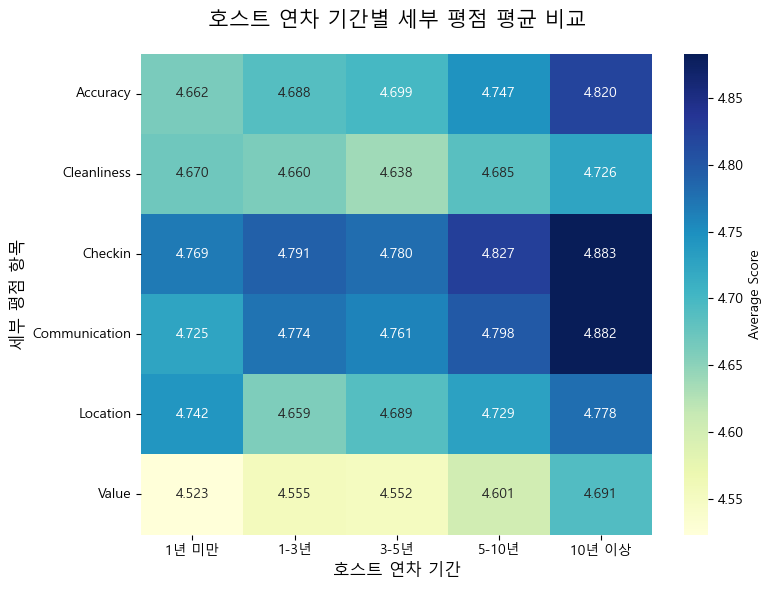

In [33]:
# 시각화: 연차별 세부 평점 비교 히트맵
plt.figure(figsize=(8, 6))

# y축으로 보내기: .T(전치) 사용
sns.heatmap(
    tenure_group_mean.T,
    annot=True,  # 수치 표시
    fmt=".3f",  # 소수점 셋째 자리까지
    cmap="YlGnBu",
    cbar_kws={"label": "Average Score"},
)

plt.title("호스트 연차 기간별 세부 평점 평균 비교", fontsize=15, pad=20)
plt.xlabel("호스트 연차 기간", fontsize=12)
plt.ylabel("세부 평점 항목", fontsize=12)

clean_ylabels = [col.replace("review_scores_", "").capitalize() for col in detail_score_cols]
plt.yticks(ticks=[i + 0.5 for i in range(len(clean_ylabels))], labels=clean_ylabels, rotation=0)

plt.tight_layout()
plt.show()

In [34]:
df_valid["host_tenure_years"]

0        15.232877
1        14.671233
2        14.646575
3        14.643836
4        14.638356
           ...    
21659     1.769863
21661     0.964384
21674     0.964384
21697     1.180822
21699     0.076712
Name: host_tenure_years, Length: 15509, dtype: float64

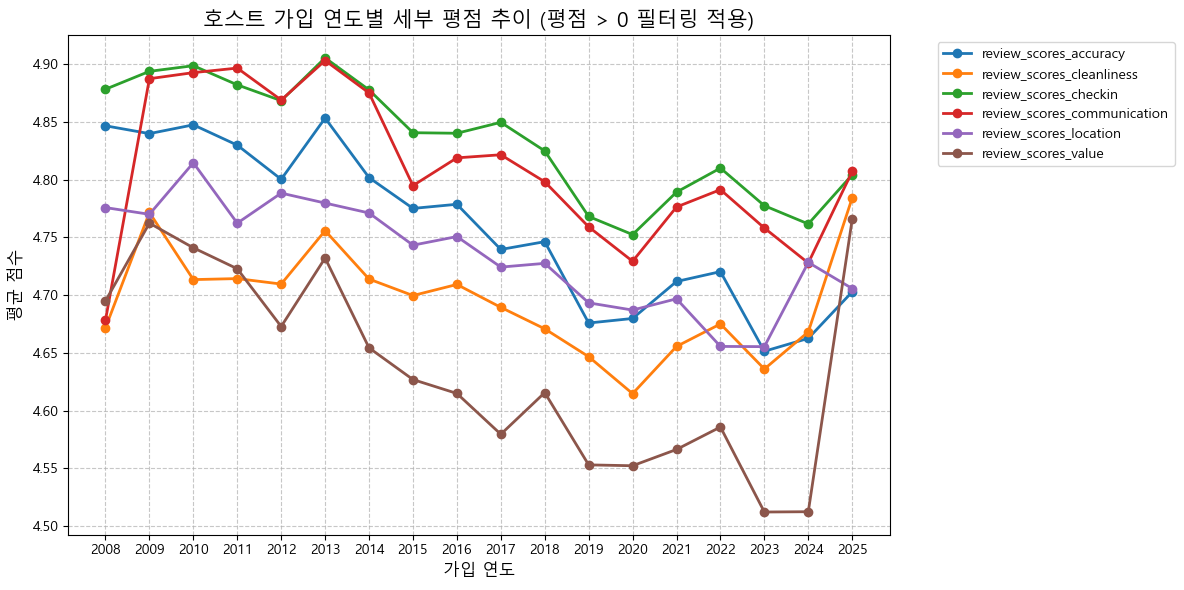

In [35]:
# 가입 연도 추출
df_valid["host_since_year"] = df_valid["host_since"].dt.year

yearly_rating_avg = df_valid.groupby("host_since_year")[detail_score_cols].mean()

# 모든 세부 평점에 대해 선 그래프 그리기
plt.figure(figsize=(12, 6))

for col in detail_score_cols:
    # yearly_rating_avg의 인덱스(연도)와 컬럼 데이터를 매칭
    plt.plot(yearly_rating_avg.index, yearly_rating_avg[col], marker="o", label=col, linewidth=2)

plt.title("호스트 가입 연도별 세부 평점 추이 (평점 > 0 필터링 적용)", fontsize=15)
plt.xlabel("가입 연도", fontsize=12)
plt.ylabel("평균 점수", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # 범례 그래프 바깥으로
plt.grid(True, linestyle="--", alpha=0.7)

# x축을 연도 단위로 표시
plt.xticks(yearly_rating_avg.index)

plt.tight_layout()
plt.show()

In [36]:
# 연차 구간 나누기
bins = [0, 1, 3, 5, 10, 20]
labels = ["1년 미만", "1-3년", "3-5년", "5-10년", "10년 이상"]

df_valid["tenure_group"] = pd.cut(df_valid["host_tenure_days"] / 365, bins=bins, labels=labels, right=False)

# 구간별 평점 평균 확인
display(df_valid.groupby("tenure_group")[detail_score_cols].mean())

,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
tenure_group,,,,,,
1년 미만,4.661590,4.670135,4.768841,4.724555,4.742264,4.523154
1-3년,4.688372,4.659990,4.790741,4.773996,4.659405,4.554786
3-5년,4.699368,4.637820,4.779562,4.760577,4.688935,4.552374
5-10년,4.746758,4.684965,4.826617,4.798389,4.728713,4.600744
10년 이상,4.820415,4.725563,4.883186,4.881905,4.777803,4.691100


In [37]:
# 구간별 데이터 개수 확인
print(df_valid["tenure_group"].value_counts().sort_index())

tenure_group
1년 미만      371
1-3년      2052
3-5년      1803
5-10년     6773
10년 이상    4510
Name: count, dtype: int64


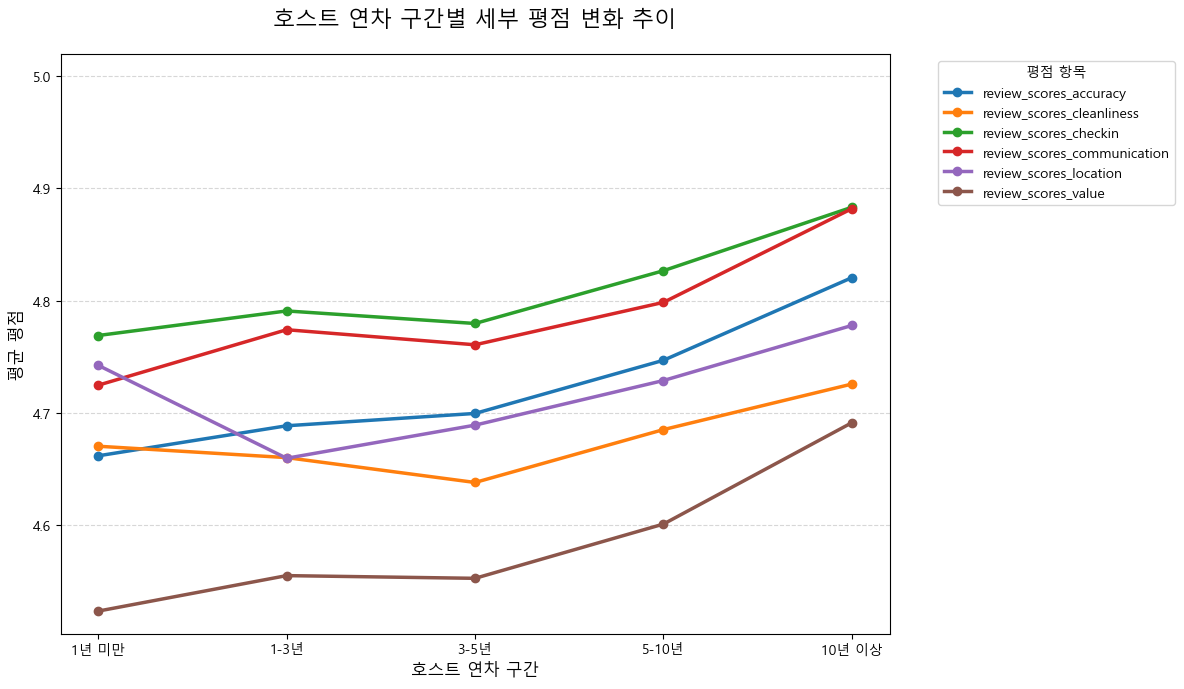

In [38]:
tenure_group_mean = df_valid.groupby("tenure_group")[detail_score_cols].mean()

# 선 그래프 시각화
plt.figure(figsize=(12, 7))

# 각 세부 항목별로 선 그리기
for col in detail_score_cols:
    plt.plot(tenure_group_mean.index, tenure_group_mean[col], marker="o", label=col, linewidth=2.5)

plt.title("호스트 연차 구간별 세부 평점 변화 추이", fontsize=16, pad=20)
plt.xlabel("호스트 연차 구간", fontsize=12)
plt.ylabel("평균 평점", fontsize=12)

plt.ylim(tenure_group_mean.min().min() - 0.02, 5.02)

plt.legend(title="평점 항목", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

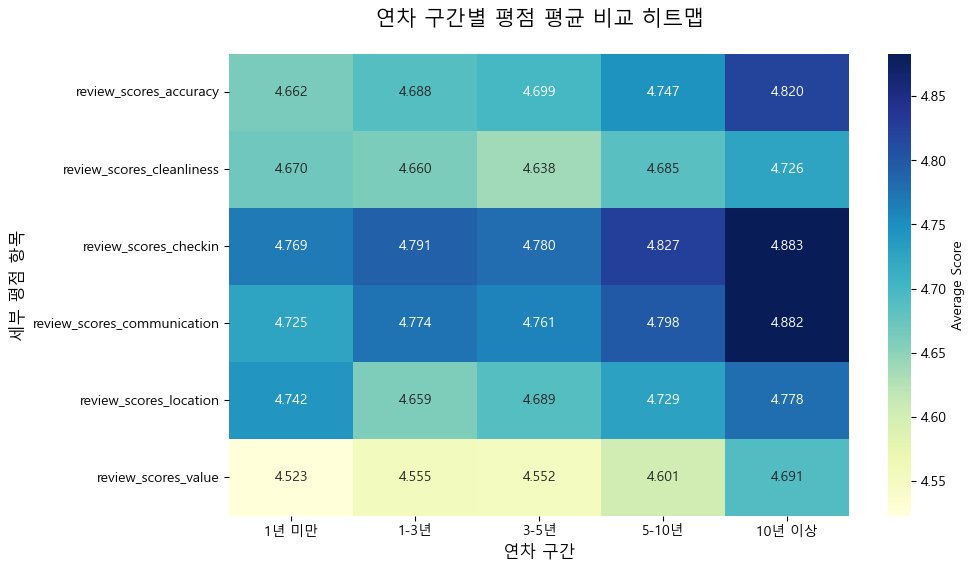

In [39]:
plt.figure(figsize=(10, 6))

# 행과 열을 바꾸어(T) 항목을 세로로, 연차를 가로로
sns.heatmap(tenure_group_mean.T, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={"label": "Average Score"})

plt.title("연차 구간별 평점 평균 비교 히트맵", fontsize=15, pad=20)
plt.ylabel("세부 평점 항목", fontsize=12)
plt.xlabel("연차 구간", fontsize=12)
plt.show()

##### 슈퍼호스트 여부에 따른 상관계수 차이 확인
경력이 길어도 슈퍼호스트가 아닌 그룹과, 경력이 짧아도 슈퍼호스트인 그룹을 비교

In [40]:
print(df_cleaned["host_is_superhost"].unique())

[False True nan]


- 리뷰는 있는데 점유율 데이터는 없을 수 있나? -> 리뷰가 0이면 occupancy도 0


# 리뷰 수에 따른 헤비 호스트 / 라이트 호스트 분리 비교

[그룹별 주요 지표 평균 비교]


,review_scores_rating,price,host_listings_count,host_acceptance_rate
review_group,,,,
Heavy (1000+),4.65,147.44,7.67,1.0
Light (<1000),4.72,181.13,77.95,0.8


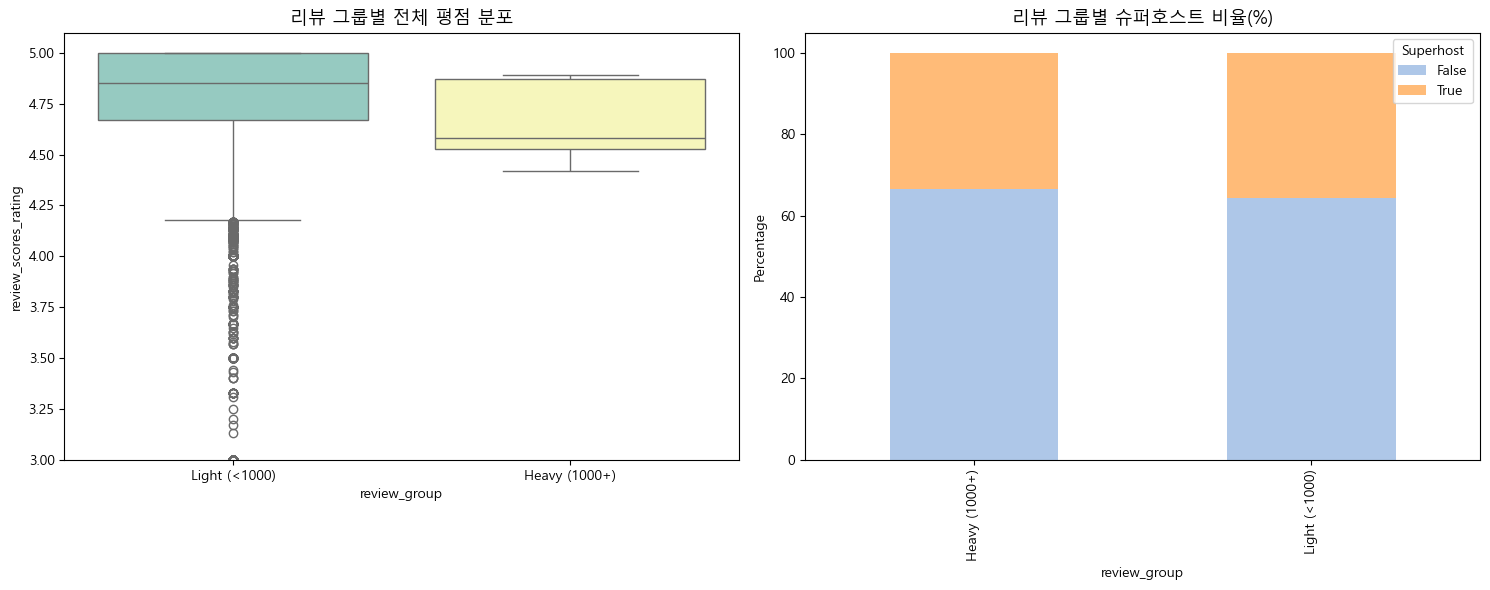

In [41]:
# 리뷰 수 그룹(헤비/라이트) 분리 (1000개를 기준으로 나눔)
df_valid["review_group"] = df_valid["number_of_reviews"].apply(
    lambda x: "Heavy (1000+)" if x >= 1000 else "Light (<1000)"
)

# 평점, 가격, 숙소 수, 수락률
metrics = ["review_scores_rating", "price", "host_listings_count", "host_acceptance_rate"]
group_comparison = df_valid.groupby("review_group")[metrics].mean().round(2)

print("[그룹별 주요 지표 평균 비교]")
display(group_comparison)

# 평점(숙소의 질적 요소) vs 숙소 수(숙소 운영 규모)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#  Boxplot 그룹별 전체 평점 분포
sns.boxplot(data=df_valid, x="review_group", y="review_scores_rating", ax=axes[0], palette="Set3")
axes[0].set_title("리뷰 그룹별 전체 평점 분포", fontsize=13)
axes[0].set_ylim(3, 5.1)  # 확대해서 보기

# 그룹별 슈퍼호스트 비율
superhost_dist = df_valid.groupby(["review_group", "host_is_superhost"]).size().unstack(fill_value=0)
superhost_dist_pct = superhost_dist.div(superhost_dist.sum(axis=1), axis=0) * 100

superhost_dist_pct.plot(kind="bar", stacked=True, ax=axes[1], color=["#aec7e8", "#ffbb78"])
axes[1].set_title("리뷰 그룹별 슈퍼호스트 비율(%)", fontsize=13)
axes[1].set_ylabel("Percentage")
axes[1].legend(title="Superhost", loc="upper right")

plt.tight_layout()
plt.show()

# 호스트 유형별 세부 평점 평균
- 한 호스트가 관리하는 숙소 개수(host_listings_count)에 따른 호스트 유형 범주화
- 세부 평점 평균과 비교

In [42]:
# 숙소 개수에 따른 호스트 유형 정의 (1개: 개인, 2~5개: 중소형, 6개 이상: 기업형)
def categorize_host(count):
    if count == 1:
        return "Individual"
    elif count <= 10:
        return "Small-Medium"
    else:
        return "Professional"


df_valid["host_business_type"] = df_valid["host_listings_count"].apply(categorize_host)

# 호스트 유형별 세부 평점 평균 비교
business_type_performance = df_valid.groupby("host_business_type")[detail_score_cols].mean()
display(business_type_performance)

,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
host_business_type,,,,,,
Individual,4.832905,4.758107,4.878825,4.889192,4.765089,4.731251
Professional,4.574168,4.518072,4.719165,4.627958,4.680277,4.340481
Small-Medium,4.782761,4.720242,4.852530,4.849820,4.727026,4.662531


In [43]:
df_valid["price"].describe().round(2)

count    15509.00
mean       181.11
std        233.27
min          7.00
25%         87.00
50%        134.00
75%        207.00
max      10271.00
Name: price, dtype: float64

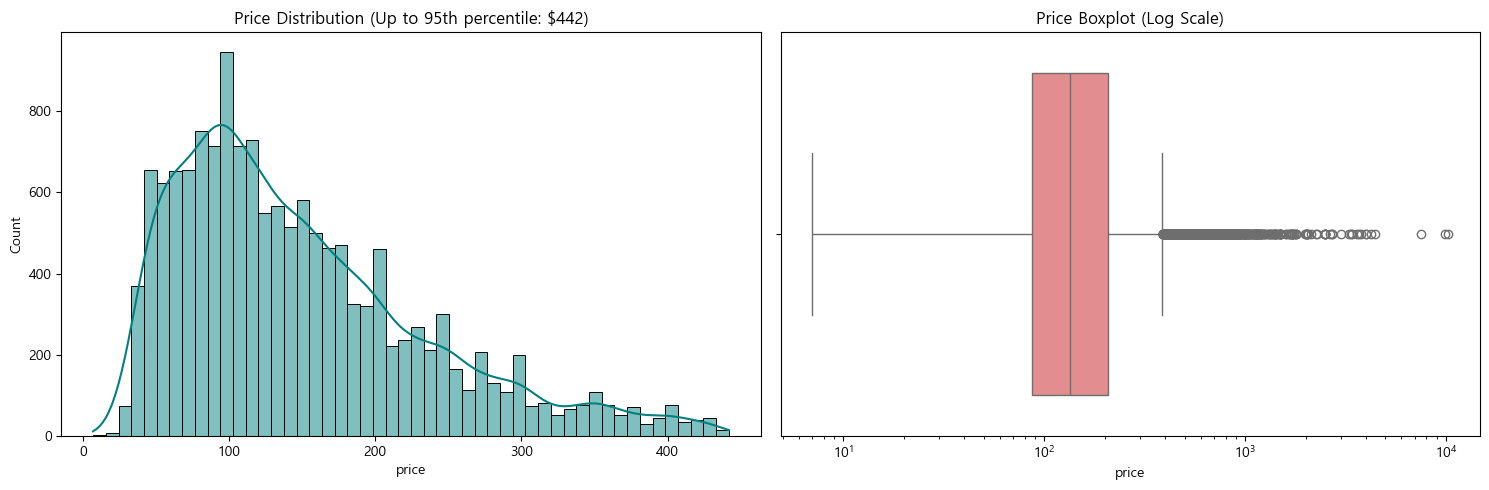

상위 1% 가격: $916.56
상위 5% 가격: $442.00


In [44]:
# 시각화 전 분위수 계산 (분포 대략 어떤지)
p95 = df_valid["price"].quantile(0.95)
p99 = df_valid["price"].quantile(0.99)

plt.figure(figsize=(15, 5))

# 히스토그램: 데이터가 몰려있는 구간 확인
plt.subplot(1, 2, 1)
sns.histplot(df_valid[df_valid["price"] <= p95]["price"], kde=True, bins=50, color="teal")
plt.title(f"Price Distribution (Up to 95th percentile: ${p95:.0f})")

# 박스플롯: 이상치 밀집도 확인 (로그 스케일)
plt.subplot(1, 2, 2)
sns.boxplot(x=df_valid["price"], color="lightcoral")
plt.xscale("log")  # 20,000까지의 간격을 보기 위해 로그 스케일 적용
plt.title("Price Boxplot (Log Scale)")

plt.tight_layout()
plt.show()

print(f"상위 1% 가격: ${p99:.2f}")
print(f"상위 5% 가격: ${p95:.2f}")

In [45]:
from scipy import stats

# 양쪽에서 1%씩(총 2%)을 제외한 절사평균 계산
trimmed_avg_price = stats.trim_mean(df_valid["price"], proportiontocut=0.01)

print(f"전체 평균 가격: ${df_valid['price'].mean():.2f}")
print(f"5% 절사 평균 가격: ${trimmed_avg_price:.2f}")

전체 평균 가격: $181.11
5% 절사 평균 가격: $167.47


In [46]:
# 상하위 1%씩 제거
lower_limit = df_valid["price"].quantile(0.01)
upper_limit = df_valid["price"].quantile(0.99)

df_price = df_valid[(df_valid["price"] >= lower_limit) & (df_valid["price"] <= upper_limit)].copy()

print(f"제거된 행 수: {len(df_valid) - len(df_price)}")
print(f"새로운 최솟값: {df_price['price'].min()}, 최댓값: {df_price['price'].max()}")
df_price["price"].describe().round(2)

제거된 행 수: 286
새로운 최솟값: 36.0, 최댓값: 900.0


count    15223.0
mean       167.2
std        122.7
min         36.0
25%         88.0
50%        133.0
75%        204.0
max        900.0
Name: price, dtype: float64

##### 절사평균으로보기

In [47]:
# 호스트유형별 가격 통계량 확인
price_stats_by_type = df_price.groupby("host_business_type")["price"].agg(["mean", "median", "std", "count"])
display(price_stats_by_type.sort_values("median", ascending=False))

,mean,median,std,count
host_business_type,,,,
Individual,175.896697,144.0,120.396313,5237
Professional,170.753304,137.0,125.573309,3405
Small-Medium,158.446133,122.0,122.442734,6581


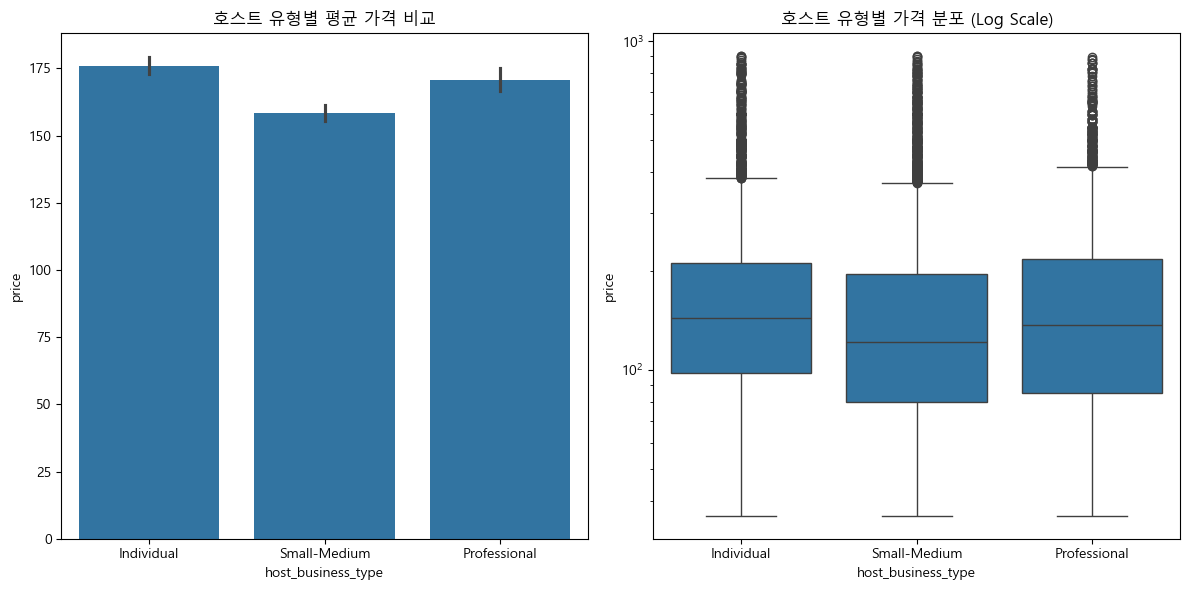

In [48]:
plt.figure(figsize=(12, 6))

# 왼쪽: 평균 가격 비교
plt.subplot(1, 2, 1)
sns.barplot(data=df_price, x="host_business_type", y="price")
plt.title("호스트 유형별 평균 가격 비교")

# 오른쪽: 가격 분포 비교 (로그 스케일 적용)
plt.subplot(1, 2, 2)
sns.boxplot(data=df_price, x="host_business_type", y="price")
plt.yscale("log")  # 가격 차이가 클 경우 로그 스케일로 시각화
plt.title("호스트 유형별 가격 분포 (Log Scale)")

plt.tight_layout()
plt.show()

In [49]:
from scipy import stats

individual_price = df_price[df_price["host_business_type"] == "Individual"]["price"]
pro_price = df_price[df_price["host_business_type"] == "Professional"]["price"]

t_stat, p_val = stats.ttest_ind(individual_price.dropna(), pro_price.dropna(), equal_var=False)
print(f"T-test 결과 P-value: {p_val:.4e}")

T-test 결과 P-value: 5.8680e-02


# 위-경도에 따른 숙소 정보 지도

# property_type 가격별로 나눠서 비율을 보면?

In [50]:
df_cleaned["price"].dtypes

dtype('float64')

In [51]:
# 0~85(25%), 85~140(50%), 140~240(75%), 240~1000(99%), 1000+(Extreme)
bins = [0, 85, 140, 240, 1000, 20000]
labels = ["Budget", "Economy", "Mid-range", "High-end", "Luxury/Extreme"]

# 가격 구간 컬럼 생성
df_cleaned["price_range"] = pd.cut(df_cleaned["price"], bins=bins, labels=labels)

# 상위 N개 property_type만 추출 (너무 많으면 그래프가 지저분해짐)
top_properties = df_cleaned["property_type"].value_counts().nlargest(10).index
df_top_props = df_cleaned[df_cleaned["property_type"].isin(top_properties)]

# 교차표 생성
prop_price_ratio = pd.crosstab(df_top_props["property_type"], df_top_props["price_range"], normalize="index")

display(prop_price_ratio.round(3))

price_range,Budget,Economy,Mid-range,High-end,Luxury/Extreme
property_type,,,,,
Entire condo,0.022,0.172,0.355,0.399,0.052
Entire home,0.080,0.265,0.306,0.322,0.026
Entire loft,0.003,0.117,0.364,0.436,0.079
Entire rental unit,0.058,0.258,0.332,0.344,0.009
Entire townhouse,0.033,0.161,0.298,0.464,0.045
Private room in condo,0.320,0.299,0.255,0.123,0.003
Private room in home,0.597,0.268,0.100,0.033,0.002
Private room in rental unit,0.590,0.264,0.112,0.032,0.001
Private room in townhouse,0.566,0.209,0.146,0.074,0.005


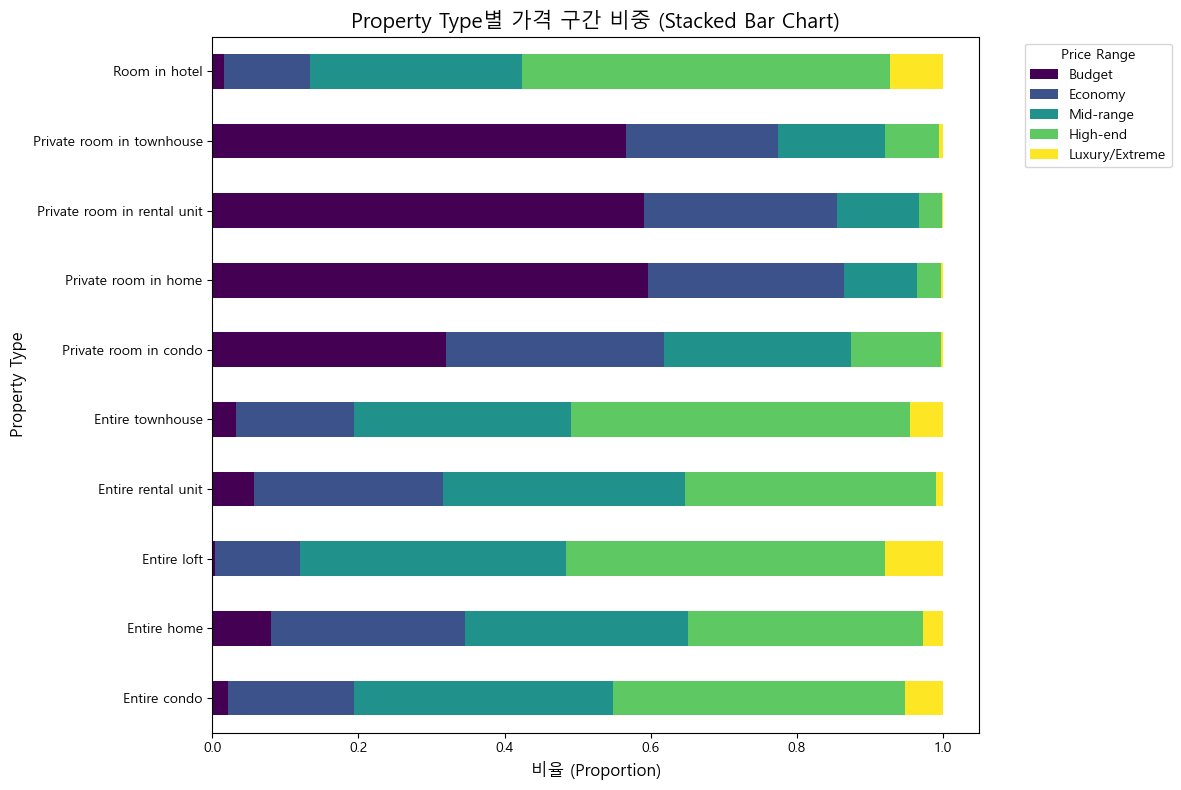

In [52]:
# 시각화
prop_price_ratio.plot(kind="barh", stacked=True, figsize=(12, 8), colormap="viridis")

plt.title("Property Type별 가격 구간 비중 (Stacked Bar Chart)", fontsize=15)
plt.xlabel("비율 (Proportion)", fontsize=12)
plt.ylabel("Property Type", fontsize=12)
plt.legend(title="Price Range", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [53]:
df_cleaned["estimated_occupancy_l365d"].dtypes

dtype('int64')

,price,estimated_occupancy_l365d
price,1.000000,-0.067122
estimated_occupancy_l365d,-0.067122,1.000000


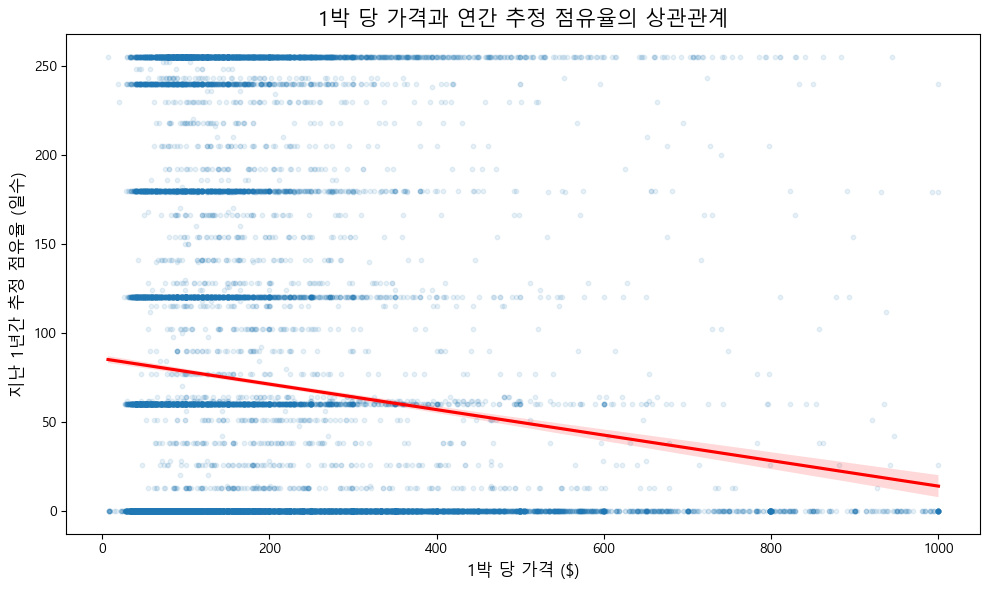

In [54]:
# 필터링
occ_data = df_cleaned[(df_cleaned["price"] <= 1000) & (df_cleaned["estimated_occupancy_l365d"] <= 365)]

# 상관계수 계산
correlation_result = occ_data[["price", "estimated_occupancy_l365d"]].corr(method="spearman")
display(correlation_result)

# 시각화
plt.figure(figsize=(10, 6))
sns.regplot(
    data=occ_data,
    x="price",
    y="estimated_occupancy_l365d",
    scatter_kws={"alpha": 0.1, "s": 10},
    line_kws={"color": "red"},
)

plt.title("1박 당 가격과 연간 추정 점유율의 상관관계", fontsize=15)
plt.xlabel("1박 당 가격 ($)", fontsize=12)
plt.ylabel("지난 1년간 추정 점유율 (일수)", fontsize=12)

plt.tight_layout()
plt.show()

In [55]:
df_cleaned[["availability_365", "estimated_occupancy_l365d"]]

,availability_365,estimated_occupancy_l365d
0,362,0
1,204,0
2,326,0
3,25,255
4,38,154
...,...,...
22303,358,0
22304,363,0
22305,99,0
22306,365,0


### 가격이 점유율에 영향을 주는지
- 가격과 점유율의 상관계수가 매우 낮음: 뉴욕 에어비앤비 이용객들이 딱 '가격' 만 보고 숙소를 정하지 않는다
- 점유율을 높이기 위해서는 단순히 가격을 낮추기 보다, 다른 요인을 보충하는 게 더 효과적일 수도(상품 설명 또는, 인증 유무 같은 요인이 효과적으로 작용하지 않을지 확인 해보려고함)

In [56]:
# 운영 중인 숙소 필터링
# 예약 가능일이 365일(공실 100%)이 아니면서, 최소 1개 이상의 리뷰가 있는 곳
active_df = df_cleaned[(df_cleaned["availability_365"] < 365) & (df_cleaned["number_of_reviews"] > 0)].copy()

In [57]:
df_cleaned["has_description"] = df_cleaned["description"].notna().astype(int)

df_cleaned["has_neighborhood_overview"] = df_cleaned["neighborhood_overview"].notna().astype(int)

df_cleaned["has_license"] = df_cleaned["license"].notna().astype(int)

# 분포 확인(Ai도움)
for col in ["has_description", "has_neighborhood_overview", "has_license"]:
    vc = df_cleaned[col].value_counts()
    pct = df_cleaned[col].mean() * 100
    print(f"  {col}: 있음={vc.get(1,0)}개({pct:.1f}%)  없음={vc.get(0,0)}개({100-pct:.1f}%)")

  has_description: 있음=21903개(98.2%)  없음=405개(1.8%)
  has_neighborhood_overview: 있음=12262개(55.0%)  없음=10046개(45.0%)
  has_license: 있음=4463개(20.0%)  없음=17845개(80.0%)


In [58]:
binary_cols = ["has_description", "has_neighborhood_overview", "has_license"]

corr_results = []
for col in binary_cols:
    mask = df_cleaned[col].notna() & df_cleaned["log_price"].notna()
    r, p = stats.pearsonr(df_cleaned.loc[mask, col], df_cleaned.loc[mask, "log_price"])
    corr_results.append(
        {
            "피처": col,
            "상관계수(r)": round(r, 4),
            "p-value": f"{p:.4e}",
            "유의성(p<0.05)": "유의함" if p < 0.05 else "유의하지 않음",
            "결정계수(r²)": f"{r**2:.2%}",
        }
    )

corr_df = pd.DataFrame(corr_results)
display(corr_df)

,피처,상관계수(r),p-value,유의성(p<0.05),결정계수(r²)
0,has_description,0.0193,3.8956e-03,유의함,0.04%
1,has_neighborhood_overview,0.1329,1.7153e-88,유의함,1.77%
2,has_license,0.1858,2.1745e-172,유의함,3.45%


#### 분석 결과
- has_description — 여전히 무시 가능. 로그 변환해도 관계 없음
- has_neighborhood_overview — r이 0.027 → 0.133으로 5배. 동네 설명을 쓰는 호스트가 더 비싼 가격대 숙소를 올리는 경향
- has_license — r=0.186, r²=3.45%로 셋 중 가장 유의미. -> Cohen 기준 Small(0.1~0.3)

##### 가격과 상품설명, 동네설명, 라이센스 유무와의 관계
- : r2 결정계수를 보면, 동네설명, 라이센스 유무가 가격에 약간의 영향을 주고있음을 알 수 있음. (전체 약 2만2천개 중1.77% : 394개 , 3.45% : 769개)

    - 의문점) 동네설명과 라이센스를 동시에 가지고 있는 호스트라면, 그렇지 않은 경우보다 비싼 숙소를 가지고 있나?

- 추가정보: 라이센스(등록, 면허 → 법인만(있음=4463개(20.0%)), 개인은 주소증명만 하면됨)
    - has_license: 있음=4463개(20.0%)  없음=17845개(80.0%)

In [59]:
(df_cleaned["has_license"] > 0).sum()

np.int64(4463)

### 가격차이를 보이는지 확인할 때, 활용할 컬럼 정리
- minimum_minimum_nights (= ‘off_peak_min’)
- maximum_minimum_nights  (= ‘peak_min’)
- minimum_maximum_nights (= 'peak_max')
- maximum_maximum_nights (= 'off_peak_max')

In [60]:
pd.set_option("display.float_format", "{:.2f}".format)

In [61]:
off_peak_min = df_cleaned["minimum_minimum_nights"].copy()
peak_min = df_cleaned["maximum_minimum_nights"].copy()
peak_max = df_cleaned["minimum_maximum_nights"].copy()
off_peak_max = df_cleaned["maximum_maximum_nights"].copy()

In [62]:
pd.concat([off_peak_min, peak_min, peak_max, off_peak_max], axis=1).describe()

,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights
count,22308.00,22308.00,22308.00,22308.00
mean,27.00,42.13,96832.65,1733373.07
std,32.12,74.70,14378031.57,60977572.22
min,1.00,1.00,1.00,1.00
25%,30.00,30.00,182.00,365.00
50%,30.00,30.00,365.00,365.00
75%,30.00,30.00,1125.00,1125.00
max,730.00,1000.00,2147483647.00,2147483647.00


### 장기(>=30)/단기(<30) 범주화

In [63]:
df_cleaned["off_peak_min"] = off_peak_min.apply(lambda x: "unlimit" if x >= 30 else "limit")
df_cleaned["peak_min"] = peak_min.apply(lambda x: "unlimit" if x >= 30 else "limit")
df_cleaned["peak_max"] = peak_max.apply(lambda x: "unlimit" if x >= 30 else "limit")
df_cleaned["off_peak_max"] = off_peak_max.apply(lambda x: "unlimit" if x >= 30 else "limit")

In [64]:
# 데이터 개수 확인
for col in ["off_peak_min", "peak_min", "peak_max", "off_peak_max"]:
    print(df_cleaned[col].value_counts())

off_peak_min
unlimit    17914
limit       4394
Name: count, dtype: int64
peak_min
unlimit    17977
limit       4331
Name: count, dtype: int64
peak_max
unlimit    20767
limit       1541
Name: count, dtype: int64
off_peak_max
unlimit    21474
limit        834
Name: count, dtype: int64


# 장기/단기 숙박 범주별 가격차이가 얼마나 나는지

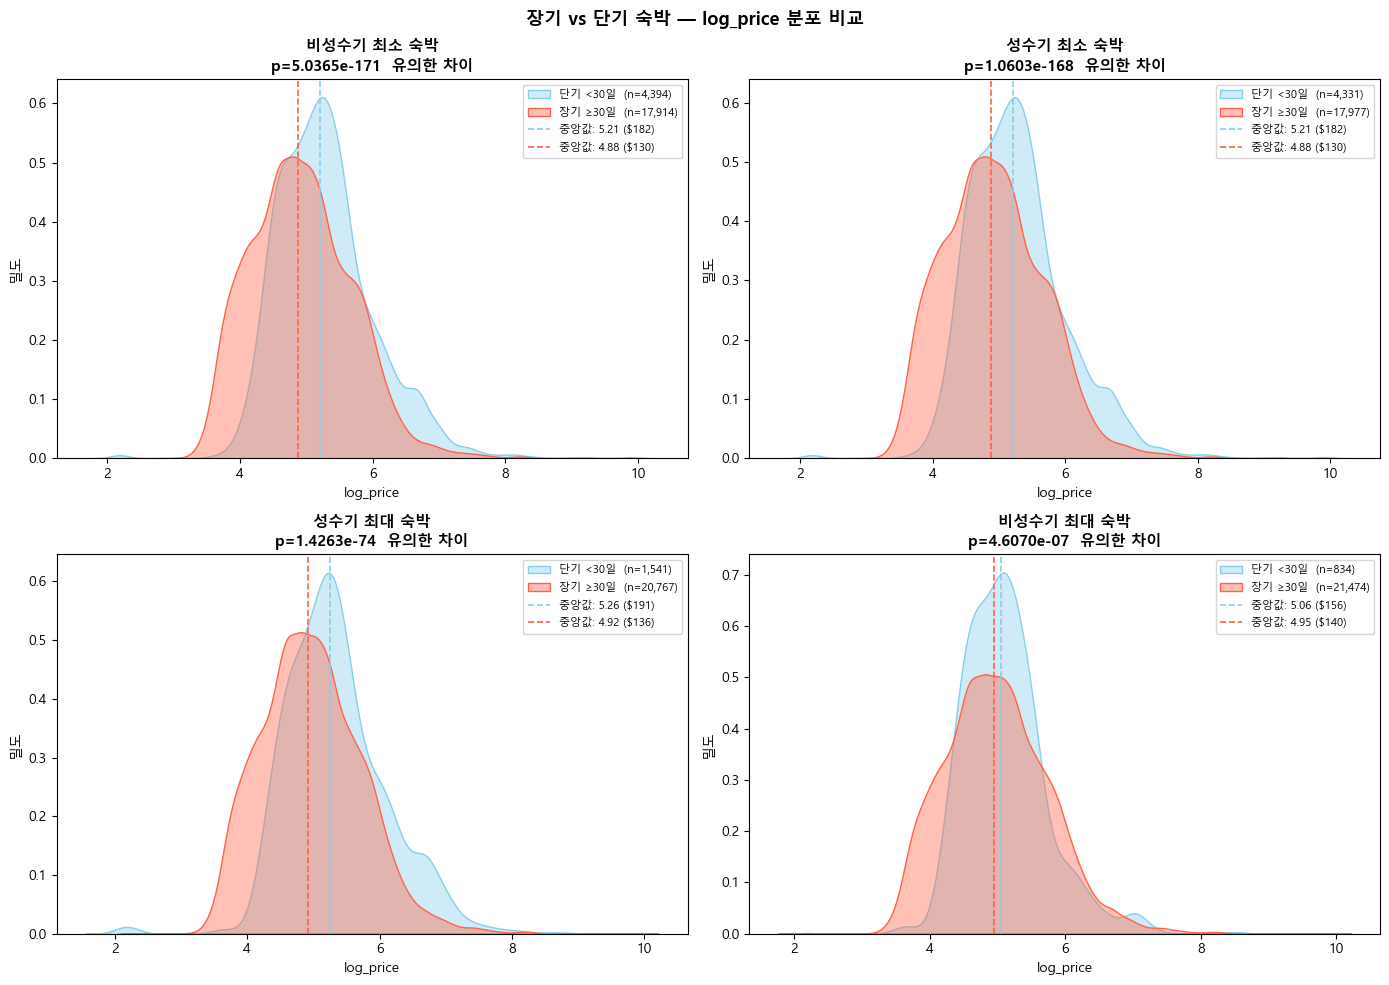

In [65]:
type_cols = {
    "off_peak_min": "비성수기 최소 숙박",
    "peak_min": "성수기 최소 숙박",
    "peak_max": "성수기 최대 숙박",
    "off_peak_max": "비성수기 최대 숙박",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, title) in zip(axes.flatten(), type_cols.items()):
    단기 = df_cleaned.loc[df_cleaned[col] == "limit", "log_price"].dropna()
    장기 = df_cleaned.loc[df_cleaned[col] == "unlimit", "log_price"].dropna()

    # KDE 분포
    sns.kdeplot(단기, ax=ax, label=f"단기 <30일  (n={len(단기):,})", fill=True, alpha=0.4, color="skyblue")
    sns.kdeplot(장기, ax=ax, label=f"장기 ≥30일  (n={len(장기):,})", fill=True, alpha=0.4, color="tomato")

    # 중앙값 수직선 + 실제 가격
    for grp, color in [(단기, "skyblue"), (장기, "tomato")]:
        med = grp.median()
        ax.axvline(med, color=color, linestyle="--", linewidth=1.2, label=f"중앙값: {med:.2f} (${np.expm1(med):.0f})")

    # Mann-Whitney 유의성 검정
    _, p = stats.mannwhitneyu(단기, 장기, alternative="two-sided")
    sig = "유의한 차이" if p < 0.05 else "유의하지 않음"

    ax.set_title(f"{title}\np={p:.4e}  {sig}", fontsize=11, fontweight="bold")
    ax.set_xlabel("log_price")
    ax.set_ylabel("밀도")
    ax.legend(fontsize=8)

plt.suptitle("장기 vs 단기 숙박 — log_price 분포 비교", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

- 단기가 장기보다 비싼 값
- 장기보다 단기 숙소 중에 고가 숙소가 더 많다는 것을 알 수 있음
- 단기는 관광객 대상, 지역 인프라가 좋거나, 인테리어가 잘 된 숙소일 가능성이 있음.
- 장기는 월세나 전세 느낌, 에어비앤비의 장기숙박 할인 정책도 고려해봐야함.
- +) 비성수기 최대 숙박 컬럼은 장단기 가격차이가 거의 없어보임 => 가격 예측 모델링할 때 제외해야 할수도